In [1]:
import geopandas, torch, torch_geometric, shapely, matplotlib, scipy, sklearn, networkx, shapefile
print("✅ All packages imported successfully!")

✅ All packages imported successfully!


In [2]:
import shapefile
import geopandas as gpd
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
from matplotlib.cm import get_cmap

from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler
from scipy.interpolate import splprep, splev
from shapely.geometry import LineString
from scipy.interpolate import interp1d

import torch
from torch_geometric.data import Data
from scipy.spatial import Delaunay

import networkx as nx
from torch_geometric.utils import to_networkx

from shapely.geometry import shape as shapely_shape

## PUSH DATASET

In [4]:
#PATH_SHP = '../data/original/waterways_merged_reprojected.shp'
PATH_SHP = '../data/push/all.shp'

# Load as GeoDataFrame
gdf = gpd.read_file(PATH_SHP)
#gdf = gdf.to_crs(epsg=3857)  # project to metric (optional, useful for distance ops)
print(gdf.shape)

(21177, 82)


In [5]:
gdf

,LAYER,LAND,ANZAHL,ART,BAUWERK,BREITE,E_NUMMER1,E_NUMMER2,EBENE,EINWOHNERZ,...,STIFFNESS,LINEMIND_2,LINEMIND_3,PRIORITY_1,FORMSTAB_1,MOVABILI_1,CANSHARE_1,COLOUR_1,FIXED_OB_1,geometry
0,barrierenlinie,TH,0,None,None,0.0,None,None,0,0.0,...,0.01,1.0,7.5,34,3,6.0,1,#333333,0,"LINESTRING (590772.63 5691024.23, 590771.07 56..."
1,barrierenlinie,TH,0,None,None,0.0,None,None,0,0.0,...,0.01,1.0,7.5,34,3,6.0,1,#660000,0,"LINESTRING (606298.05 5698000.96, 606343.05 56..."
2,barrierenlinie,TH,0,None,None,0.0,None,None,0,0.0,...,0.01,1.0,7.5,34,3,6.0,1,#660000,0,"LINESTRING (584654.62 5694267.65, 584700.34 56..."
3,barrierenlinie,TH,0,None,None,0.0,None,None,0,0.0,...,0.01,1.0,7.5,34,3,6.0,1,#660000,0,"LINESTRING (584918.8 5694221.88, 584950.22 569..."
4,barrierenlinie,TH,0,None,None,0.0,None,None,0,0.0,...,0.01,1.0,7.5,34,3,6.0,1,#660000,0,"LINESTRING (590168.73 5693345.42, 590216.11 56..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21172,verkehrslinie,TH,0,None,None,6.0,None,None,0,0.0,...,0.10,1.0,7.5,22,3,7.0,0,#333333,0,"LINESTRING (606377.01 5694619, 606388.55 56946..."
21173,verkehrslinie,TH,0,None,None,6.0,None,None,0,0.0,...,0.10,1.0,7.5,22,3,7.0,0,#333333,0,"LINESTRING (607261.7 5690883.91, 607299.37 569..."
21174,verkehrslinie,TH,0,None,None,6.0,None,None,0,0.0,...,0.10,1.0,7.5,22,3,7.0,0,#333333,0,"LINESTRING (606614.89 5694699.78, 606638.19 56..."
21175,verkehrslinie,TH,0,None,None,6.0,None,None,0,0.0,...,0.10,1.0,7.5,22,3,7.0,0,#333333,0,"LINESTRING (605733.35 5692991.28, 605786.72 56..."


## Load Input Data

In [4]:
synthetic_1 = np.load(f'../data/final_dataset/sequence/real-world-river-displaced_close.npy')
synthetic_2 = np.load(f'../data/final_dataset/sequence/real-world-river-displaced_far.npy')
original = np.load(f'../data/final_dataset/sequence//real-world-river.npy')[:15000]

In [67]:
# Create data structure of the three lines
lines_merged = [original[:15000], synthetic_1[:15000], synthetic_2[:15000]]

In [68]:
def point_to_polyline_distance(point, polyline):
    """
    point: (2,)
    polyline: (N, 2)
    returns: shortest distance from point to any segment in the polyline
    """
    A = polyline[:-1]   # (N-1, 2)
    B = polyline[1:]    # (N-1, 2)
    AP = point - A      # (N-1, 2)
    AB = B - A          # (N-1, 2)
    AB_norm_sq = np.sum(AB**2, axis=1, keepdims=True)  # (N-1,1)
    
    t = np.clip(np.sum(AP*AB, axis=1, keepdims=True) / AB_norm_sq, 0, 1)  # (N-1,1)
    proj = A + t * AB  # projection on segment (N-1, 2)
    dist = np.linalg.norm(point - proj, axis=1)  # (N-1,)
    return np.min(dist)

In [69]:
def compute_orientation_angles(coords):
    """
    coords: (N, 2)
    returns: (N, 1) array of angles in radians
    Angle at point i = direction from i to i+1
    For the last point, we copy the angle of the previous point.
    """
    N = len(coords)
    angles = np.zeros(N)

    for i in range(N - 1):
        dx = coords[i+1, 0] - coords[i, 0]
        dy = coords[i+1, 1] - coords[i, 1]
        angles[i] = np.arctan2(dy, dx)  # range (-pi, pi)

    # Last point: reuse previous angle
    angles[-1] = angles[-2]
    
    return angles.reshape(-1, 1)


In [70]:
def make_graphs(lines):
    """
    lines: [normalized_original, normalized_synthetic_1, normalized_synthetic_2]
    Goal: predict shift from synthetic_1 -> synthetic_2
    """
    graphs = []
    num_lines = len(lines)
    num_seqs, seq_len, _ = lines[0].shape

    for seq_idx in range(num_seqs):  # iterate over sequences
        node_features_list = []
        edge_list = []

        for line_id, line_array in enumerate(lines):
            coords = line_array[seq_idx]  # (seq_len, 2)

            # Compute distances to the two other lines (for features)
            other_coords = [lines[i][seq_idx] for i in range(num_lines) if i != line_id]
            #d1 = np.linalg.norm(coords - other_coords[0], axis=1, keepdims=True)
            #d2 = np.linalg.norm(coords - other_coords[1], axis=1, keepdims=True)

            #TBC: andere Distanz?
            d1 = [point_to_polyline_distance(p, other_coords[0]) for p in coords]
            d2 = [point_to_polyline_distance(p, other_coords[1]) for p in coords]
            d1 = np.array(d1).reshape(-1,1)
            d2 = np.array(d2).reshape(-1,1)
            
            #Angles and curvature 
            angles = compute_orientation_angles(coords)
            #curvature = np.diff(angles, prepend=angles[0])

            # Node features: [line_id, x, y, seq_len, dist1, dist2]
            line_ids = np.full((seq_len, 1), line_id)
            seq_lengths = np.full((seq_len, 1), seq_len)
            node_features = np.hstack([line_ids, coords, seq_lengths, d1, d2, angles])
            node_features_list.append(node_features)

            # --- Within-line edges ---
            start_idx = line_id * seq_len
            src = np.arange(start_idx, start_idx + seq_len - 1)
            dst = np.arange(start_idx + 1, start_idx + seq_len)
            edges = np.vstack([np.hstack([src, dst]), np.hstack([dst, src])])
            edge_list.append(edges)

        # Cross-line edges (connect same index across lines)
        for i in range(seq_len):
            for l1 in range(num_lines):
                for l2 in range(l1 + 1, num_lines):
                    n1 = l1 * seq_len + i
                    n2 = l2 * seq_len + i
                    edge_list.append(np.array([[n1, n2], [n2, n1]]))

        # Stack features and edges
        node_features = np.vstack(node_features_list)  # (192, 6)
        edge_index = np.hstack(edge_list)              # shape (2, num_edges)

        # === TARGET: shift only for synthetic_1 nodes ===
        syn1 = lines[1][seq_idx]  # input
        syn2 = lines[2][seq_idx]  # desired output
        shift = syn2 - syn1       # Δx, Δy for each point in synthetic_1

        # Create y: zeros for other lines, shift for synthetic_1
        y = np.zeros((num_lines * seq_len, 2), dtype=np.float32)
        start_idx = 1 * seq_len  # synthetic_1 block
        y[start_idx:start_idx+seq_len] = shift

        # Convert to PyTorch tensors
        x = torch.tensor(node_features, dtype=torch.float)
        edge_index = torch.tensor(edge_index, dtype=torch.long)
        y = torch.tensor(y, dtype=torch.float)

        data = Data(x=x, edge_index=edge_index, y=y)
        graphs.append(data)

    return graphs


In [71]:
graphs_seq = make_graphs(lines_merged)

In [73]:
def make_all_graphs_delaunay(lines):
    """
    Build one graph per sequence, combining all 3 lines,
    using Delaunay triangulation for edges.
    
    Args:
        lines: list of 3 arrays, each shape (num_seqs, seq_len, 2)
    
    Returns:
        List of PyTorch Geometric Data objects
    """
    num_lines = len(lines)               # should be 3
    num_seqs, seq_len, _ = lines[0].shape
    graphs = []
    
    for seq_idx in range(num_seqs):
        # --- 1) Stack all points (192, 2) ---
        coords = np.vstack([lines[i][seq_idx] for i in range(num_lines)])
        
        # --- 2) Node features ---
        # line_id (192, 1)
        line_ids = np.repeat(np.arange(num_lines), seq_len).reshape(-1, 1)
        # seq_len (192, 1)
        seq_lengths = np.full((coords.shape[0], 1), seq_len)

        # Distances to the two other lines
        dists = []
        for li in range(num_lines):
            node_coords = lines[li][seq_idx]           # (64, 2)
            others = [lines[j][seq_idx] for j in range(num_lines) if j != li]
            d1 = np.linalg.norm(node_coords - others[0], axis=1, keepdims=True)
            d2 = np.linalg.norm(node_coords - others[1], axis=1, keepdims=True)
            dists.append(np.hstack([d1, d2]))          # (64, 2)
        dists = np.vstack(dists)                       # (192, 2)

        # Final node features: [line_id, x, y, seq_len, dist1, dist2]
        node_features = np.hstack([line_ids, coords, seq_lengths, dists])
        x = torch.tensor(node_features, dtype=torch.float)

        # --- 3) Delaunay edges ---
        tri = Delaunay(coords)
        edges = set()
        for simplex in tri.simplices:     # 3 vertices per triangle
            for i in range(3):
                for j in range(i+1, 3):
                    a, b = simplex[i], simplex[j]
                    edges.add((a, b))
                    edges.add((b, a))     # undirected

        edge_index = torch.tensor(list(zip(*edges)), dtype=torch.long)

        # --- 4) Create Data object ---
        graphs.append(Data(x=x, edge_index=edge_index))
    
    return graphs

In [74]:
graphs_delaunay = make_all_graphs_delaunay(lines_merged)

### Save Results

In [75]:
#torch.save(graphs_seq, f'../data/final_dataset/graph/graphs_sequential.pt')
torch.save(graphs_delaunay, f'../data/final_dataset/graph//graphs_delaunay.pt')

### Ploting Graphs

In [58]:
def plot_graph(data):
    # Convert PyG Data -> NetworkX
    G = to_networkx(data, to_undirected=True)

    # Extract node positions (x,y from features)
    pos = {i: (float(data.x[i][1]), float(data.x[i][2])) for i in range(data.num_nodes)}

    # Node colors by line_id
    color_map = ["#143642", "#EC9A29", "#A8201A"]
    colors = [color_map[int(data.x[i][0].item())] for i in range(data.num_nodes)]

    plt.figure(figsize=(8, 6))
    plt.title(f'Constructed Graph')
    plt.xlabel('X')
    plt.ylabel('Y')
    nx.draw(G, pos,
            node_size=10,
            node_color=colors,
            edge_color="#B3B5B6A6",
            alpha=0.8)
    plt.show()

In [66]:
graph = graphs_seq   
g0 = graph[0]       

df = pd.DataFrame(
    g0.x.numpy(),
    columns=["line_id", "x", "y", "seq_len", "dist1", "dist2", "angle"]
)
#print(df.head())
print(df[df["line_id"] == 1].head())


    line_id         x         y  seq_len     dist1     dist2     angle
64      1.0  0.779891  0.542059     64.0  0.000043  0.000084  1.358453
65      1.0  0.779930  0.542241     64.0  0.000028  0.000084  1.345910
66      1.0  0.779971  0.542422     64.0  0.000032  0.000081  1.247784
67      1.0  0.780031  0.542599     64.0  0.000026  0.000078  1.159862
68      1.0  0.780105  0.542770     64.0  0.000031  0.000061  1.022231


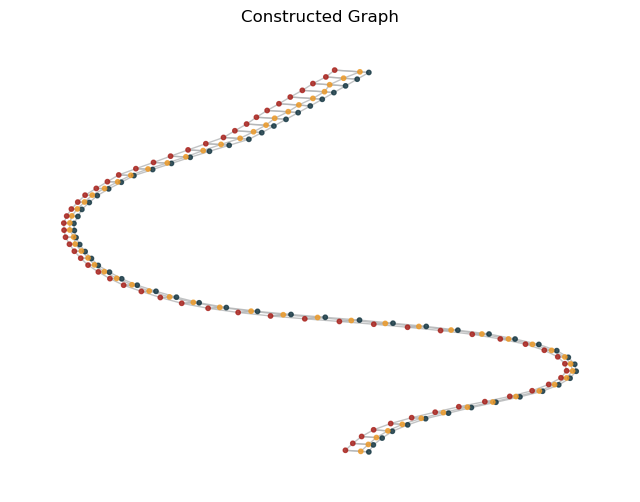

In [47]:
plot_graph(g0)